<div align="center">
  <img src="/Users/rinaanuar/Desktop/endka_intro_to_ml/image.png" />
</div>


<a id="import"></a>
<h2><b><span style>🍷 Step 1.1 : </span><span>Import Libraries</span></b></h2>

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score,roc_curve
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix


<a id="import"></a>
<h2><b><span style>🍷 Step 1.2 : </span><span>Some set up </span></b></h2>

In [18]:
pd.options.mode.copy_on_write = True #Allow re-write on variable
sns.set_style('darkgrid') #Seaborn style

In [19]:
sns.color_palette("Set2")


[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

In [20]:
sns.set_palette("Set2")

<a id="import"></a>
<h2><b><span style>🍷 Step 2.1 : </span><span>Importing data</span></b></h2>

In [21]:
data = pd.read_csv('../data/wine_quality.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


<a id="info"></a>
<h2><b><span>🍷 Step 2.2 : </span><span>Data Information</span></b></h2>

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [23]:
data.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.000000,7.215307,1.296434,3.800000,6.400000,7.000000,7.700000,15.900000
volatile acidity,6497.000000,0.339666,0.164636,0.080000,0.230000,0.290000,0.400000,1.580000
citric acid,6497.000000,0.318633,0.145318,0.000000,0.250000,0.310000,0.390000,1.660000
residual sugar,6497.000000,5.443235,4.757804,0.600000,1.800000,3.000000,8.100000,65.800000
chlorides,6497.000000,0.056034,0.035034,0.009000,0.038000,0.047000,0.065000,0.611000
free sulfur dioxide,6497.000000,30.525319,17.749400,1.000000,17.000000,29.000000,41.000000,289.000000
total sulfur dioxide,6497.000000,115.744574,56.521855,6.000000,77.000000,118.000000,156.000000,440.000000
density,6497.000000,0.994697,0.002999,0.987110,0.992340,0.994890,0.996990,1.038980
pH,6497.000000,3.218501,0.160787,2.720000,3.110000,3.210000,3.320000,4.010000
sulphates,6497.000000,0.531268,0.148806,0.220000,0.430000,0.510000,0.600000,2.000000


In [24]:
data = data.drop_duplicates()

In [25]:
data.shape

(5320, 13)

<a id="info"></a>
<h2><b><span>🍷 Step 2.3 : </span><span>Features Information</span></b></h2>

| #  | Feature               | Type    | Meaning / Description                                                   | Interpretation in wine context                                             |
|----|-----------------------|---------|-------------------------------------------------------------------------|----------------------------------------------------------------------------|
| 0  | fixed acidity         | float64 | Non-volatile (fixed) acids: tartaric, malic, etc.                      | Main component of total acidity; affects freshness and structure           |
| 1  | volatile acidity      | float64 | Volatile acids, mainly acetic acid                                     | High values give vinegar-like smell/taste and lower perceived quality      |
| 2  | citric acid           | float64 | Citric acid                                                            | Adds freshness and brightness; affects acidity balance                     |
| 3  | residual sugar        | float64 | Remaining sugar after fermentation                                     | Determines sweetness level (dry vs semi-sweet vs sweet)                    |
| 4  | chlorides             | float64 | Salt content (mostly sodium chloride)                                  | High levels can lead to salty/flat taste and lower quality                 |
| 5  | free sulfur dioxide   | float64 | Free SO₂ (active, unbound form)                                        | Acts as antioxidant/preservative; excessive levels give sharp SO₂ smell    |
| 6  | total sulfur dioxide  | float64 | Total SO₂ (free + bound)                                               | Affects shelf life and microbial stability; too high can be a defect       |
| 7  | density               | float64 | Density of the wine                                                    | Related to sugar and alcohol; indirectly reflects style and composition    |
| 8  | pH                    | float64 | Acidity on the pH scale                                                | Lower pH → more acidic, fresher, and more stable; higher pH → softer taste |
| 9  | sulphates             | float64 | Sulphate compounds (e.g., potassium sulphate)                          | Influence structure and mouthfeel; linked to sulfur dioxide management     |
| 10 | alcohol               | float64 | Alcohol content (% by volume)                                          | Often positively related to perceived quality (within reasonable range)    |
| 11 | quality               | int64   | Sensory quality score (panel rating)                                   | Target variable for prediction (classification/regression)                 |
| 12 | type                  | object  | Wine type (e.g., "red" or "white")                                     | Categorical feature; shifts distributions of almost all other variables    |


<a id="info"></a>
<h2><b><span>🍷 Step 3.1 : </span><span>Handling Missing Values, Encoding And Delete Duplicates </span></b></h2>

In [26]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

<a id="info"></a>
<h4><b><span> -> There is no missing values</b></span></h4>

In [27]:
data = data.drop_duplicates()
data.shape

(5320, 13)

In [28]:
data["type"].value_counts()

type
white    3961
red      1359
Name: count, dtype: int64

<a id="info"></a>
<h4><b><span> -> Make 1 = the category you’re more interested in or that is more common it is not rule just choice</b></span></h4>

# need to add how we encoding it 

In [29]:
data["type_white"] = (data["type"] == "white").astype(int)
data = data.drop(columns='type')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


<a id="info"></a>
<h2><b><span>🍷 Step 3.3 : </span><span>Visualization</span></b></h2>

In [30]:
data.rename(columns = {"fixed acidity": "fixed_acidity",
                       "volatile acidity": "volatile_acidity",
                       "citric acid": "citric_acid",
                       "residual sugar": "residual_sugar",
                       "chlorides": "chlorides",
                       "free sulfur dioxide": "free_sulfur_dioxide",
                       "total sulfur dioxide": "total_sulfur_dioxide"
                       },
            inplace = True)

In [31]:
data.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type_white'],
      dtype='object')

In [32]:
# Create a list of DataFrame columns
columns = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
           'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
           'pH', 'sulphates', 'alcohol','type_white']

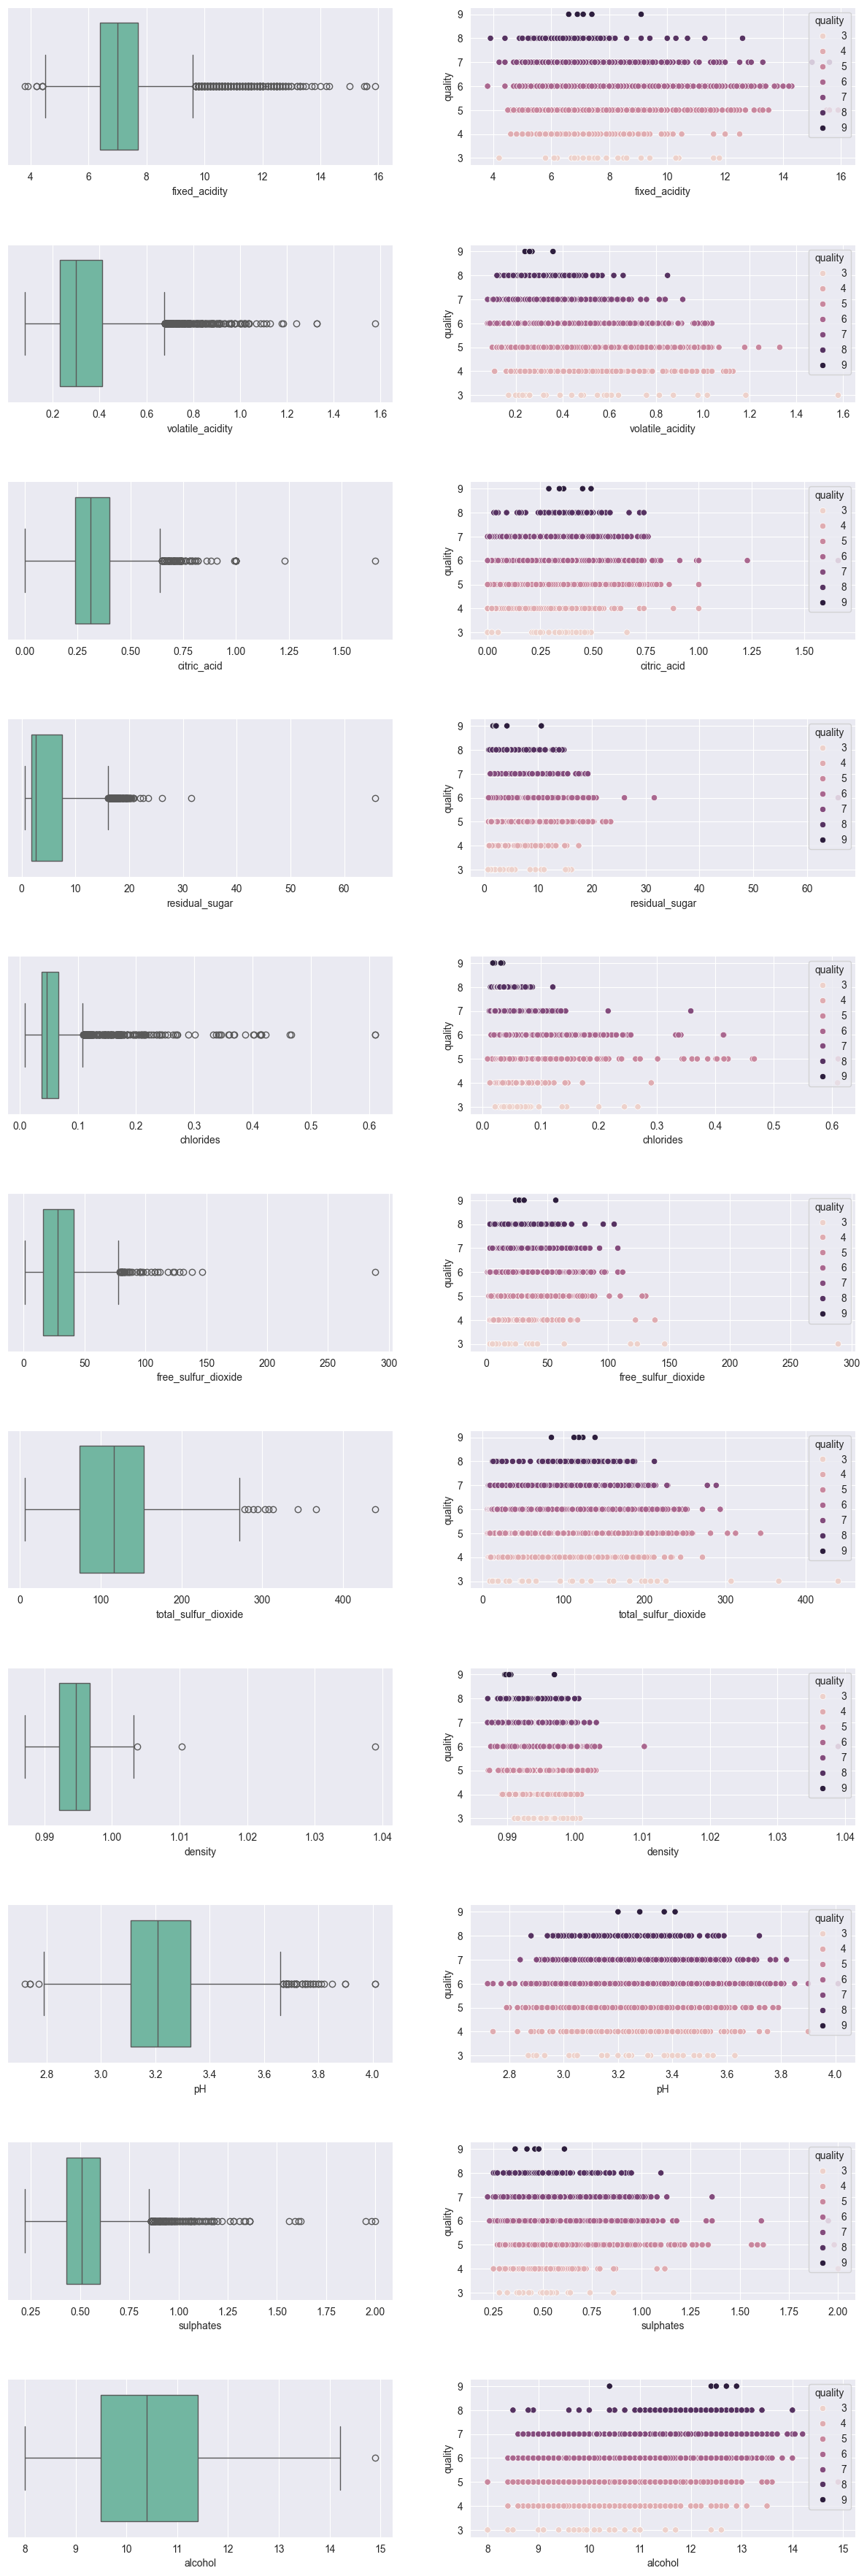

In [33]:
fig, ax = plt.subplots(11, 2, figsize=(15, 45))
plt.subplots_adjust(hspace = 0.5)
for i in range(11) :
    # Boxplot
    sns.boxplot(x=columns[i], data=data, ax=ax[i, 0])
    # Scatter
    sns.scatterplot(x=columns[i], y='quality', data=data, hue='quality', ax=ax[i, 1])

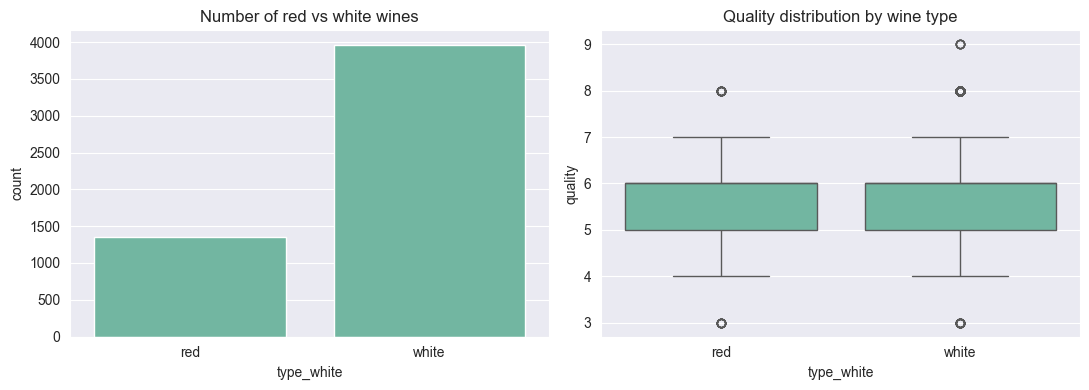

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

#count of red vs white
sns.countplot(x='type_white', data=data, ax=ax[0])
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['red', 'white'])
ax[0].set_title('Number of red vs white wines')

#quality distribution by wine type
sns.boxplot(x='type_white', y='quality', data=data, ax=ax[1])
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['red', 'white'])
ax[1].set_title('Quality distribution by wine type')

plt.tight_layout()
plt.show()

# Mb write something accordig to boxplots  write that we have outlaiers so need to use RobsS

In [35]:
'''sns.pairplot(data, hue='quality', corner = True, palette='Purples')#mb we dont need this we can drop it '''

"sns.pairplot(data, hue='quality', corner = True, palette='Purples')#mb we dont need this we can drop it "

# mb do some plots Gaukhar plots 

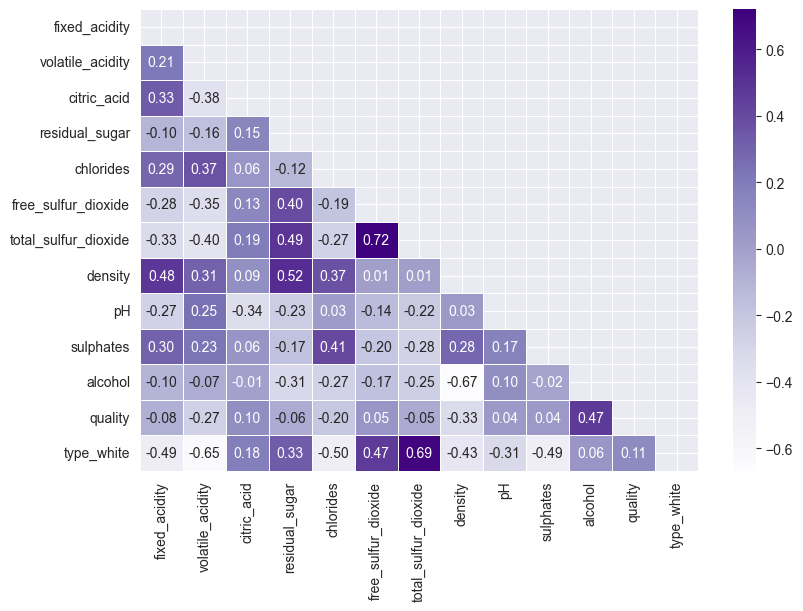

In [36]:
corr = data.corr()
# cmap = sns.diverging_palette(-1, 1, s=100, l=50, n=15, center="dark", as_cmap=True)
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', linewidth=0.5, cmap='Purples', mask=np.triu(corr))
plt.show()

# add text as in Aray's about corr

<a id="info"></a>
<h2><span> </span>Dropping one of the SO₂ features

The dataset contains two highly correlated sulfur dioxide features:

- `free_sulfur_dioxide`
- `total_sulfur_dioxide` (which already includes the free part)

Their strong correlation means they carry largely overlapping information and can introduce multicollinearity in linear models.  
To reduce redundancy and simplify the feature space, we **dropped `free_sulfur_dioxide` and kept `total_sulfur_dioxide`** as a more general measure of sulfur dioxide content.<span></h2>

In [37]:
data = data.drop(columns='free_sulfur_dioxide')

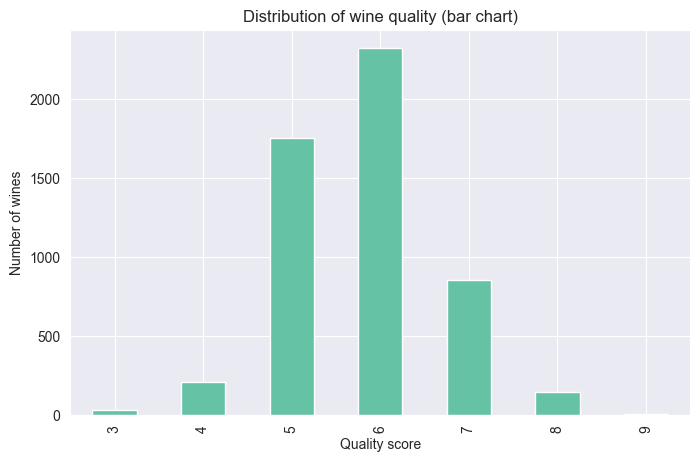

In [38]:
plt.figure(figsize=(8, 5))
data["quality"].value_counts().sort_index().plot(kind='bar')

plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.title("Distribution of wine quality (bar chart)")
plt.show()

# write some conslusion for plots 


<h2><b><span>🍷 Step 3.4 : </span><span>Target Categorizing</span></b></h2>

In [39]:
data = data.replace({'quality' : {  9 : 1,#HighQuality
                                    8 : 1,
                                    7 : 1,
                                    6 : 1,
                                    5 : 0,#LowQuality
                                    4 : 0,
                                    3 : 0,
        }}
)

In [40]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,34.0,0.9978,3.51,0.56,9.4,0,0
1,7.8,0.88,0.00,2.6,0.098,67.0,0.9968,3.20,0.68,9.8,0,0
2,7.8,0.76,0.04,2.3,0.092,54.0,0.9970,3.26,0.65,9.8,0,0
3,11.2,0.28,0.56,1.9,0.075,60.0,0.9980,3.16,0.58,9.8,1,0
5,7.4,0.66,0.00,1.8,0.075,40.0,0.9978,3.51,0.56,9.4,0,0


In [41]:
data["quality"].value_counts()

quality
1    3332
0    1988
Name: count, dtype: int64

# write here that we have a imbalanced data 

<h2><b><span>🍷 Step 3.5 : </span><span>Scaling</span></b></h2>

In [42]:
def distplot(feature, frame, ax, color='b'):#need we this we can just remove it !
    sns.histplot(
        frame[feature],
        color=color,
        kde=True,
        stat='density',
        bins=30,
        ax=ax
    )
    ax.set_title(f"Distribution for {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")


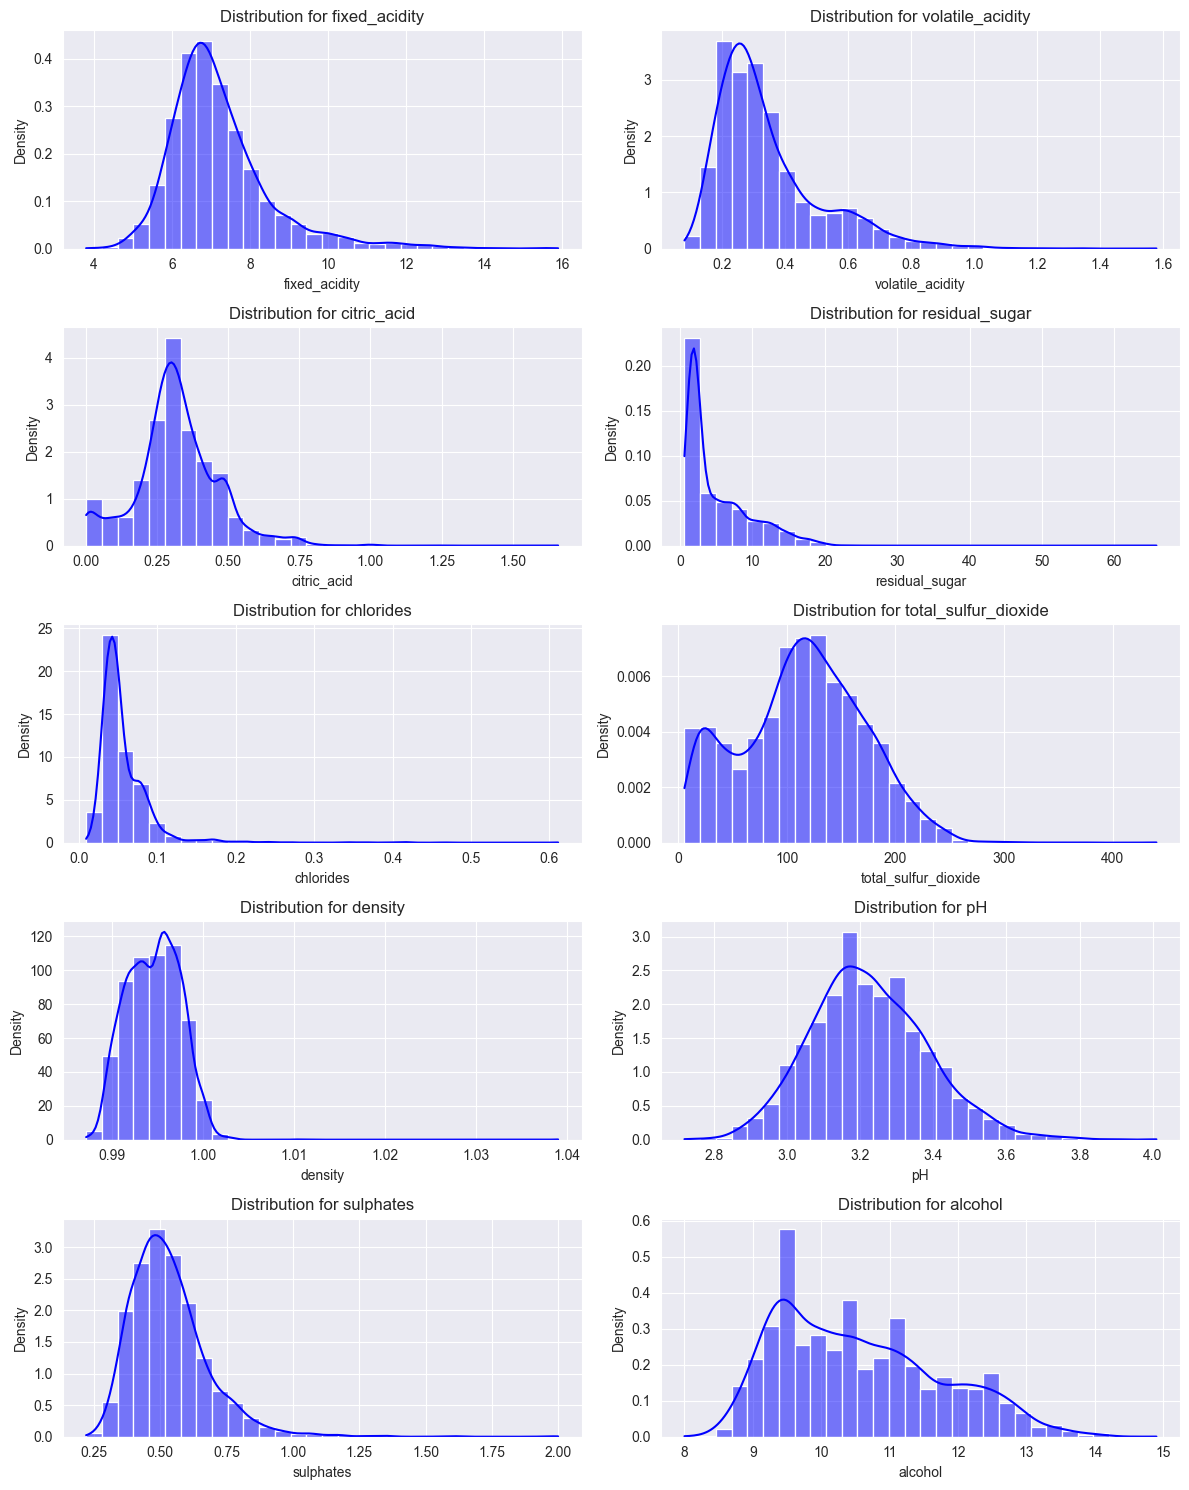

In [43]:
num_cols = [
    'fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

fig, axes = plt.subplots(5, 2, figsize=(12, 15))
axes = axes.flatten()
for ax, feat in zip(axes, num_cols):
    distplot(feat, data, ax=ax)

plt.tight_layout()
plt.show()


<p style="font-size: 18px; font-family: 'Times New Roman';">As we see in the histogram, numerical values are distributed over different value ranges. We will use .... have some outlaiers need to use RobustScaler.</p>

In [44]:
# Create X from DataFrame and y as Target
X_temp = data.drop(columns=['quality'])
y = data.quality

In [45]:
num_cols = [c for c in X_temp.columns if c != 'type_white']

scaler = StandardScaler()
X_temp[num_cols] = scaler.fit_transform(X_temp[num_cols])

X = X_temp

X.describe().T.style.background_gradient(axis=0, cmap='Purples')

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,5320.000000,0.000000,1.000094,-2.588145,-0.617772,-0.163070,0.367415,6.581671
volatile_acidity,5320.000000,-0.000000,1.000094,-1.570028,-0.678405,-0.262314,0.391543,7.346207
citric_acid,5320.000000,0.000000,1.000094,-2.164515,-0.533454,-0.057728,0.553919,9.116989
residual_sugar,5320.000000,0.000000,1.000094,-0.988604,-0.721923,-0.521912,0.544812,13.501067
chlorides,5320.000000,0.000000,1.000094,-1.293816,-0.507052,-0.262884,0.252582,15.038318
total_sulfur_dioxide,5320.000000,-0.000000,1.000094,-1.904371,-0.706532,0.033310,0.689479,5.740662
density,5320.000000,0.000000,1.000094,-2.504125,-0.787562,0.038682,0.753636,14.988637
pH,5320.000000,0.000000,1.000094,-3.146985,-0.715020,-0.091439,0.656858,4.897208
sulphates,5320.000000,-0.000000,1.000094,-2.092831,-0.690295,-0.155996,0.445090,9.795325
alcohol,5320.000000,0.000000,1.000094,-2.149768,-0.884822,-0.125855,0.717443,3.668983



<h1><b><span>🍷 Step 4 : </span><span>MODELIGN</span></b></h1>

<h2><b><span>🍷 Step 4.1 : </span><span>Initialization</span></b></h2>

In [46]:
features = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates',
       'alcohol', 'type_white']
X = data[features]
y = data['quality']

In [47]:
# Splite Dataframe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

<h2><b><span>🍷 Step 4.2 : </span><span>Logistic Regression</span></b></h2>

In [48]:
#Parameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2'] 
}

log_reg = LogisticRegression(random_state=42, max_iter=1000)

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(log_reg, param_grid, cv=cv, scoring='roc_auc')
grid_search.fit(X_train, y_train)

best_log_reg = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://sci

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


In [49]:

#Evaluating tuned model
y_pred = best_log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_log_reg.predict_proba(X_test)[:, 1])

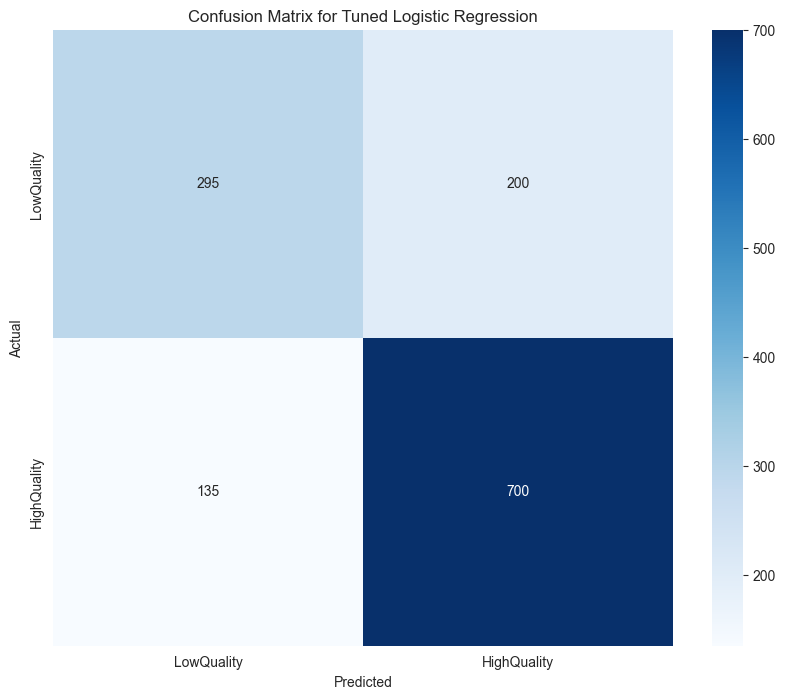

In [50]:
#Plotting confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["LowQuality", "HighQuality"], yticklabels=["LowQuality", "HighQuality"])
plt.title("Confusion Matrix for Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

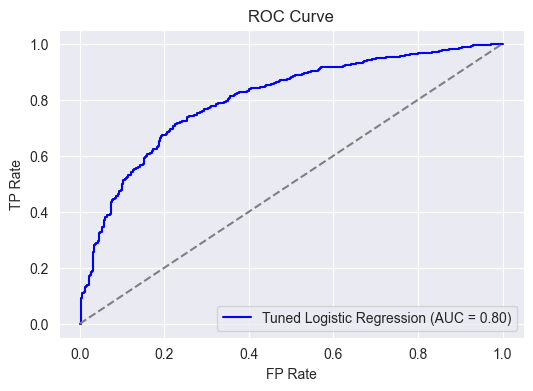

In [51]:
#Plotting ROC-AUC curve
fpr, tpr, thresholds = roc_curve(y_test, best_log_reg.predict_proba(X_test)[:, 1])

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'Tuned Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [52]:
#Metrics
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(class_report)
print("\nROC-AUC Score:", roc_auc)

Accuracy: 0.7481203007518797

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.60      0.64       495
           1       0.78      0.84      0.81       835

    accuracy                           0.75      1330
   macro avg       0.73      0.72      0.72      1330
weighted avg       0.74      0.75      0.74      1330


ROC-AUC Score: 0.8021000423395633


In [53]:
"""import numpy as np#idk mb remove it 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

idx_good = list(model.classes_).index(1)

# 2. Probabilities of "good" on the test set
y_proba_good = model.predict_proba(X_test)[:, idx_good]
f11={}
# 3. Scan thresholds
for threshold in np.arange(0.0, 1.01, 0.02):
    # Convert probabilities → string labels
    y_pred = np.where(y_proba_good >= threshold, 1, 0)

    # Now both y_test and y_pred are strings
    f1 = f1_score(y_test, y_pred, pos_label=1)
    f11[threshold]=f1
    print(f"Threshold: {threshold:.2f}, F1 Score: {f1:.4f}")
    if 0.82<=f1<=0.89:
        print(f"Optimal threshold found: {threshold:.2f}")
        print("Model quality: Good; a solid, reliable model.")
        break"""

'import numpy as np#idk mb remove it \nfrom sklearn.model_selection import train_test_split\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import f1_score\n\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, random_state=42, stratify=y\n)\n\nmodel = RandomForestClassifier(random_state=42)\nmodel.fit(X_train, y_train)\n\nidx_good = list(model.classes_).index(1)\n\n# 2. Probabilities of "good" on the test set\ny_proba_good = model.predict_proba(X_test)[:, idx_good]\nf11={}\n# 3. Scan thresholds\nfor threshold in np.arange(0.0, 1.01, 0.02):\n    # Convert probabilities → string labels\n    y_pred = np.where(y_proba_good >= threshold, 1, 0)\n\n    # Now both y_test and y_pred are strings\n    f1 = f1_score(y_test, y_pred, pos_label=1)\n    f11[threshold]=f1\n    print(f"Threshold: {threshold:.2f}, F1 Score: {f1:.4f}")\n    if 0.82<=f1<=0.89:\n        print(f"Optimal threshold found: {threshold:.2f}")\n        print("Model quality: Go

In [54]:
# 1. Probabilities of class 1 ("HighQuality")
idx_pos = list(best_log_reg.classes_).index(1)
y_probs = best_log_reg.predict_proba(X_test)[:, idx_pos]

# 2. Scan thresholds
thresholds = np.linspace(0, 1, 200)

tps, fps, fns, tns = [], [], [], []
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)

    # confusion matrix elements
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tps.append(tp)
    fps.append(fp)
    fns.append(fn)
    tns.append(tn)

    # metrics for positive class = 1
    precisions.append(precision_score(y_test, y_pred, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, pos_label=1, zero_division=0))
    f1s.append(f1_score(y_test, y_pred, pos_label=1, zero_division=0))


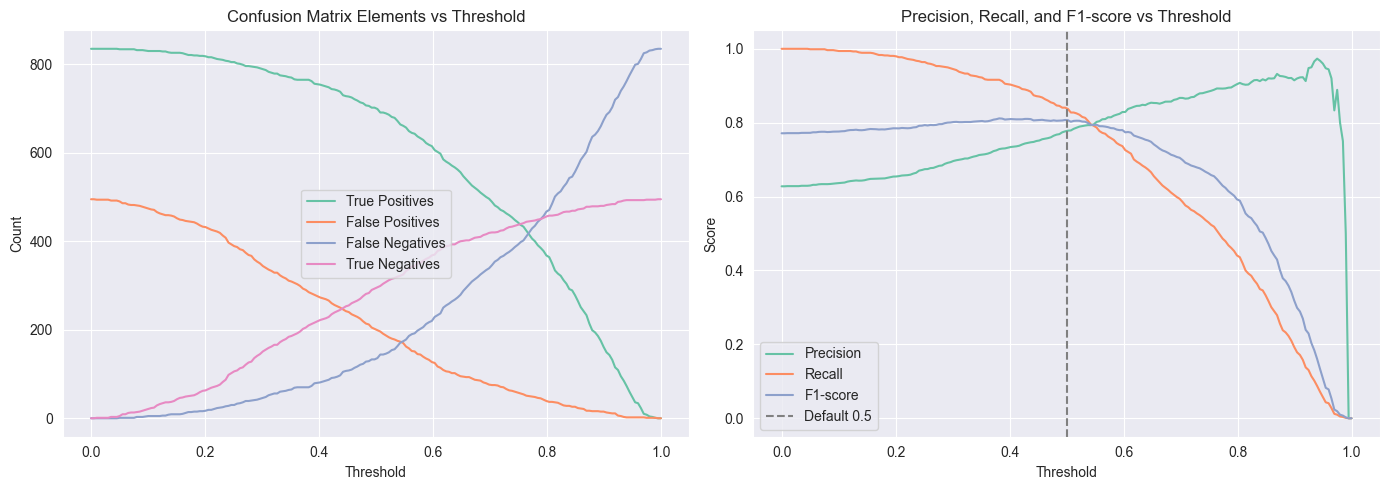

Best threshold by F1: 0.382, F1 = 0.8117


In [55]:
# 3. Plot: confusion matrix elements vs threshold  +  metrics vs threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: TP / FP / FN / TN
axes[0].plot(thresholds, tps, label='True Positives')
axes[0].plot(thresholds, fps, label='False Positives')
axes[0].plot(thresholds, fns, label='False Negatives')
axes[0].plot(thresholds, tns, label='True Negatives')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Count')
axes[0].set_title('Confusion Matrix Elements vs Threshold')
axes[0].legend()
axes[0].grid(True)

# Right: Precision / Recall / F1
axes[1].plot(thresholds, precisions, label='Precision')
axes[1].plot(thresholds, recalls, label='Recall')
axes[1].plot(thresholds, f1s, label='F1-score')
axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Default 0.5')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall, and F1-score vs Threshold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 4. Best threshold by F1 (optional)
best_idx = np.argmax(f1s)
best_thr = thresholds[best_idx]
best_f1 = f1s[best_idx]
print(f"Best threshold by F1: {best_thr:.3f}, F1 = {best_f1:.4f}")

<h2><b><span>🍷 Step 4.3 : </span><span>K-Neighbors Classifier</span></b></h2>

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

accuracy_scores = []
f1_scores = []

neighbors = [5, 11, 31, 50, 100]

# 1. Считаем accuracy и F1 для каждого k
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)          # или X_train_scaled, если ты скейлишь
    y_pred = knn.predict(X_test)       # и X_test_scaled

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    accuracy_scores.append(acc)
    f1_scores.append(f1)

# 2. Выбор best_k с допуском по F1
max_f1 = max(f1_scores)
tolerance = 0.002  # все k, у которых F1 >= max_f1 - 0.002
candidate_ks = [k for k, f in zip(neighbors, f1_scores) if max_f1 - f <= tolerance]
best_k = min(candidate_ks)

# метрики для выбранного k
idx_best = neighbors.index(best_k)
best_f1 = f1_scores[idx_best]
best_acc = accuracy_scores[idx_best]

print(f"Best k (with tolerance) = {best_k}")
print(f"F1 = {best_f1:.4f}, Accuracy = {best_acc:.4f}")



Best k (with tolerance) = 31
F1 = 0.7607, Accuracy = 0.6707


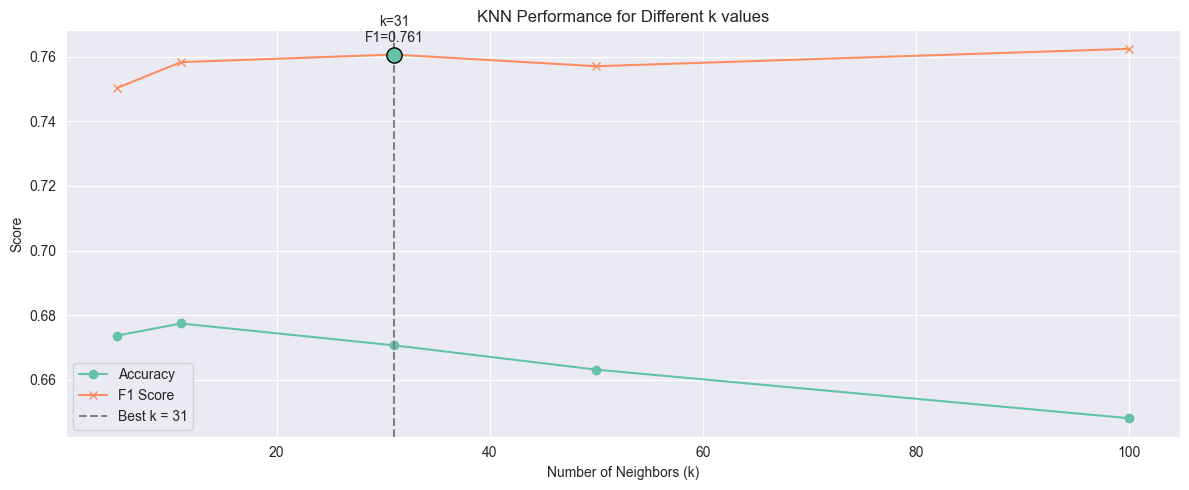

In [57]:

# 3. График
plt.figure(figsize=(12, 5))

plt.plot(neighbors, accuracy_scores, label='Accuracy', marker='o')
plt.plot(neighbors, f1_scores, label='F1 Score', marker='x')

# вертикальная линия по выбранному k
plt.axvline(x=best_k, color='gray', linestyle='--', label=f'Best k = {best_k}')

# точка лучшего F1
plt.scatter([best_k], [best_f1], s=120, edgecolors='black', zorder=5)
plt.text(best_k, best_f1 + 0.003,
         f'k={best_k}\nF1={best_f1:.3f}',
         ha='center', va='bottom')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Score')
plt.title('KNN Performance for Different k values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
#Initializing the model
knn = KNeighborsClassifier(n_neighbors=31)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [59]:
#Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1])

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(class_report)
print("\nROC-AUC Score:", roc_auc)

Accuracy: 0.6706766917293233

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.40      0.47       495
           1       0.70      0.83      0.76       835

    accuracy                           0.67      1330
   macro avg       0.64      0.61      0.62      1330
weighted avg       0.66      0.67      0.65      1330


ROC-AUC Score: 0.7080771789753826


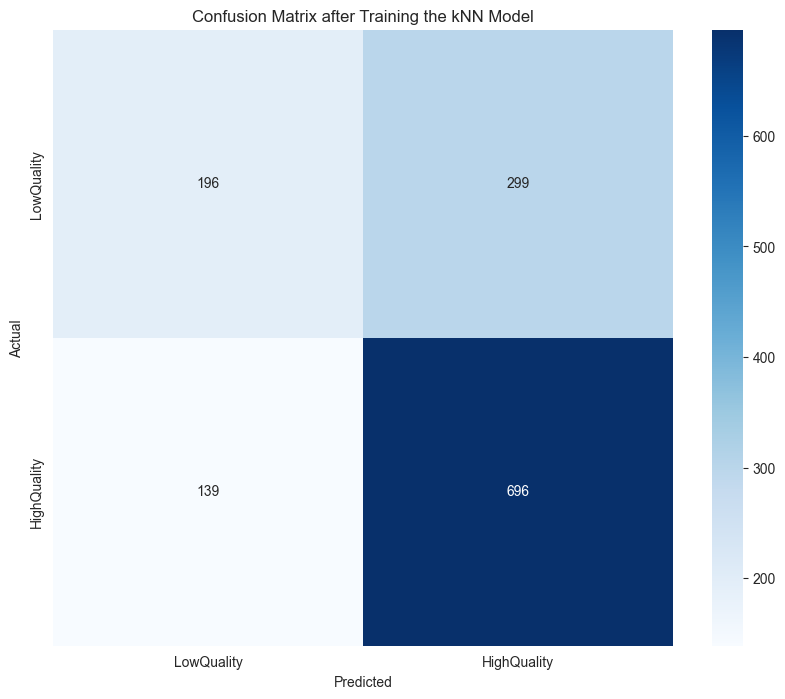

In [60]:
#Plotting confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["LowQuality", "HighQuality"], yticklabels=["LowQuality", "HighQuality"])
plt.title("Confusion Matrix after Training the kNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

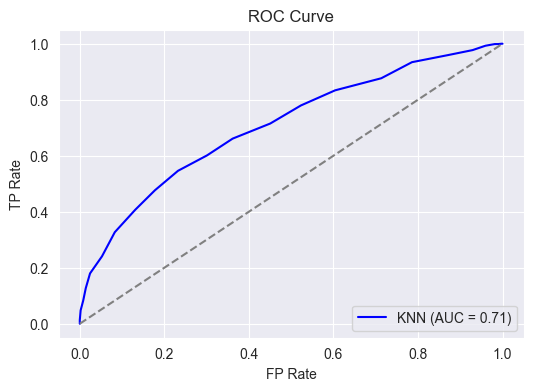

In [61]:
#Plotting ROC-AUC curve
fpr, tpr, thresholds = roc_curve(y_test, knn.predict_proba(X_test)[:, 1])
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

<h2><b><span>🍷 Step 4.4 : </span><span>SVM</span></b></h2>

In [62]:
# from sklearn.svm import SVC
# from sklearn.model_selection import StratifiedKFold, GridSearchCV
# from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# # Base SVC (probability=True for ROC curve)
# svc_base = SVC(probability=True, random_state=42, class_weight='balanced')

# # Parameter grid (можешь поменять C, kernel, gamma)
# param_grid = {
#     'C': [0.1, 1, 10, 100],
#     'kernel': ['rbf', 'linear'],
#     'gamma': ['scale', 'auto']
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid_svc = GridSearchCV(
#     estimator=svc_base,
#     param_grid=param_grid,
#     cv=cv,
#     scoring='roc_auc',
#     n_jobs=-1
# )

# grid_svc.fit(X_train, y_train)

# best_svc = grid_svc.best_estimator_
# print("Best Parameters:", grid_svc.best_params_)


In [63]:
# Predictions
y_pred = best_svc.predict(X_test)
y_prob = best_svc.predict_proba(X_test)[:, 1]  # prob for class 1 (HighQuality)

# Metrics
accuracy_svc = accuracy_score(y_test, y_pred)
class_report_svc = classification_report(y_test, y_pred)
roc_auc_svc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy_svc)
print("\nClassification Report:\n", class_report_svc)
print("ROC-AUC Score:", roc_auc_svc)


NameError: name 'best_svc' is not defined

In [ ]:
cm_svc = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svc,
            annot=True, fmt='d', cmap="Greens",
            xticklabels=['LowQuality (0)', 'HighQuality (1)'],
            yticklabels=['LowQuality (0)', 'HighQuality (1)'])
plt.title("Confusion Matrix for SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr_svc, tpr_svc,
         label=f'SVC (AUC = {roc_auc_svc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.title('ROC Curve – Tuned SVC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()